In [10]:
# --- Celda 1.1: Importaciones y Carga de Librerías Offline ---
import os
import numpy as np
import pandas as pd
import glob
import ROOT
import time
import traceback
from multiprocessing import Pool, cpu_count
from functools import partial

In [11]:
# Esta es la parte MÁS IMPORTANTE:
# Asegúrate de que estás corriendo este Jupyter Lab desde una terminal
# donde ANTES hiciste: source /ruta/a/auger/offline/this-auger-offline.sh

AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError(
        "AUGEROFFLINEROOT no definido. "
        "Reinicia Jupyter Lab desde una terminal donde hayas "
        "hecho: "
        " 'aug_set_version offline 4.0.1-icrc23-prod1-root6' "   
        " 'source /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6/bin/this-auger-offline.sh'."
    )

print(f"AUGEROFFLINEROOT encontrado en: {AugerOfflineRoot}")

# Cargar las librerías necesarias
print("Cargando librerías de Auger Offline...")
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    lib_path = os.path.join(AugerOfflineRoot, "lib", lib)
    if not os.path.exists(lib_path):
        raise FileNotFoundError(f"No se encontró la librería: {lib_path}")
    
    # Usamos gSystem.Load que es más robusto en PyROOT
    status = ROOT.gSystem.Load(lib_path)
    if status < 0:
        raise ImportError(f"Error cargando la librería: {lib_path}")

print("Librerías cargadas correctamente. ¡Listo para trabajar! 🚀")

AUGEROFFLINEROOT encontrado en: /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6
Cargando librerías de Auger Offline...
Librerías cargadas correctamente. ¡Listo para trabajar! 🚀


In [12]:
# --- Celda 2.1: Funciones Auxiliares y Principales (con nMuones_MC) ---

def getModuleList(counter, sim=True):
    """
    Obtiene la lista de objetos 'Module' (segmentos de detector)
    asociados a un 'Counter' (estación UMD).
    
    Parameters:
    ----------
    counter : ROOT.mevt.Counter
        La estación UMD de la cual extraer los módulos.
    sim : bool, default=True
        Flag para indicar si son datos de simulación.
        - True (Simulación): IDs de módulo son 0, 1, 2...
        - False (Datos Reales): IDs de módulo son 100, 101, 102...
    """
    possibleModules = range(0, 6) if sim else range(100, 116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules

def readADST_surface_v12(fname, is_mc_simulation=True):
    """
    Leer un archivo ADST (1 fila por MÓDULO).
    
    Esta función es el corazón del pipeline de procesamiento. Itera sobre
    cada evento (lluvia) en un archivo ADST y extrae la información
    relevante a nivel de MÓDULO de UMD (el nivel más granular).
    
    Lógica Clave:
    1. Itera sobre el MDEvent (mEvent.CountersBegin()) para encontrar
       TODOS los counters UMD (tanto Infill '104k' como Anillo Denso '90k').
    2. Usa el SDEvent como "diccionario" de geometría para obtener r y phi.
    3. NO filtra por 'IsLowGainSaturated', en su lugar, guarda un flag.
    4. Versión HÍBRIDA (v12) para calcular la posicion:
    
    Combina la lógica original (v7) para el Anillo Denso con la corrección
    de Euler (v10) para el Infill:
    - Si ID es 90k (UMD): Se confía en GetAzimuthSP (Mantiene consistencia con Money Plots).
    - Si ID es Infill/Std: Se fuerza la Rotación de Euler (Arregla el bug de proyección).

    Versión DEBUG: Calcula y guarda 3 definiciones de Phi para comparación para 
                   el infill y mostrar que esta mal el uso del SP en el infill:
    a. Euler (3D Correcto)
    b. Ground (2D Proyección simple)
    c. SP (Nativo de Auger)

    5. Guarda la señal REC ('nMuones_REC') y la señal MC ('nMuones_MC')
       para cada módulo individual para el UMD.

    6. Para el SD guarda las señal REC + MC: separa la parte EM
       de Muonica para el MC; y la total y Muonica para el REC.

    """
    
    print(f"Iniciando lectura de: {os.path.basename(fname)}")
    
    if not os.path.exists(fname):
        print(f"Advertencia: Archivo no encontrado {fname}")
        return pd.DataFrame() # Retorna DF vacío 

    # --- Inicialización de ROOT ---
    files = ROOT.std.vector('string')()
    files.push_back(fname)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    
    file1.ReadDetectorGeometry(geo) # Ignoramos fallos (Warnings de TStreamerInfo)
    file1.SetBuffers(event)

    data = []
    event_count = 0
    start_time = time.time()

    # --- COMIENZA EL BUCLE DE EVENTOS ---
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        event_count += 1
        if event_count % 500 == 0:
            print(f"... procesados {event_count} eventos.")
        
        # --- Info Global del Evento (Lluvia) ---
        event_id_lluvia = event.GetEventId()
        
        # Simulación
        MCShower = event.GetGenShower()
        mc_energy = MCShower.GetEnergy()
        logE_MC = np.log10(mc_energy) if mc_energy > 0 else np.nan
        theta_MC = MCShower.GetZenith() * 180.0 / np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0 / np.pi
        primary = MCShower.GetShortPrimaryName()
        
        # Reconstrucción
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        rec_energy = sShower.GetEnergy()
        logE_REC = np.log10(rec_energy) if rec_energy > 0 else np.nan
        
        # Ángulos
        theta_REC_deg = sShower.GetZenith() * 180.0 / np.pi
        phi_REC_deg = sShower.GetAzimuth() * 180.0 / np.pi

        rec_theta_rad = sShower.GetZenith()
        rec_phi_rad = sShower.GetAzimuth()
        
        # Core
        pos_core = sShower.GetCoreSiteCS()
    
        # --- Bucle sobre los COUNTERS ---
        mEvent = event.GetMDEvent()
        counterIterator = mEvent.CountersBegin()
        countersEnd = mEvent.CountersEnd()
        
        while counterIterator != countersEnd:
            
            counter = counterIterator.__deref__() # Objeto Counter (estación)
            counterId = counter.GetId()           
            sdId = counter.GetSdPartnerId()    

            # Buscamos la estación de superficie (SD) asociada
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            # --- Corte de Calidad 1: Geometría ---
            # Si no hay sdStation, no podemos calcular r_core ni phi_plane.
            # Ese counter no sirve para el análisis de asimetría.
            if sdStation is None:
                counterIterator += 1 # Avanzamos al siguiente counter
                continue 

            # --- Corte de Calidad 2: Saturación (Corte Diferido) ---
            # Guardamos el flag, como discutimos, en lugar de filtrar.
            is_sd_saturated = sdStation.IsLowGainSaturated()
            
            # Datos básicos de la reconstruccion
            sdSignal = sdStation.GetTotalSignal()
            sdSignal_err = sdStation.GetTotalSignalError()
            sdMuonSignal = sdStation.GetMuonSignal() # Suele ser 0 en Reco estándar




            # --- 📡 CÁLCULO DE COMPONENTES MC (CONTEO DE PARTÍCULAS) 📡 ---
            mc_sd_n_muon = np.nan
            mc_sd_n_em = np.nan # Suma de electrones + fotones
            
            if hasattr(sEvent, "HasSimStation") and sEvent.HasSimStation(sdId):
                simStation = sEvent.GetSimStationById(sdId)
                
                # Usamos los métodos que el Hunter encontró como NO NULOS
                if hasattr(simStation, "GetNumberOfMuons"):
                    mc_sd_n_muon = float(simStation.GetNumberOfMuons())
                
                # Para la parte EM sumamos electrones y fotones
                n_e = 0.0
                n_gamma = 0.0
                if hasattr(simStation, "GetNumberOfElectrons"):
                    n_e = float(simStation.GetNumberOfElectrons())
                if hasattr(simStation, "GetNumberOfPhotons"):
                    n_gamma = float(simStation.GetNumberOfPhotons())
                
                mc_sd_n_em = n_e + n_gamma


            
                
            r_core_err = sdStation.GetSPDistanceError() 

            
            
            # ============================================================
            # 🔀 BIFURCACIÓN CORRECTA (Lazy Loading) 🔀
            # ============================================================

            # --- 1. PHI NATIVO (SP) ---
            # Para Infill (100k+), SP suele ser absoluto (Norte), hay que restar la lluvia.
            # Para Denso (90k), SP ya es relativo.
            val_sp = sdStation.GetAzimuthSP()
            if sdId >= 100000:
                phi_sp = val_sp - rec_phi_rad
            else:
                phi_sp = val_sp
            phi_plane_sp = (phi_sp + 2*np.pi) % (2*np.pi)
            
            if 90000 <= sdId < 100000:
                # --- CASO A: ANILLO DENSO (UMD) ---
                # NO PEDIMOS geo.GetStationPosition() AQUÍ.
                # Usamos directamente las variables pre-calculadas del SP.
                
                phi_rel = sdStation.GetAzimuthSP()
                r_final = sdStation.GetSPDistance()
                
                x_plane = r_final * np.cos(phi_rel)
                y_plane = r_final * np.sin(phi_rel)
                phi_plane_final = (phi_rel + 2 * np.pi) % (2 * np.pi)
                
                # Definimos una posición dummy o calculada simple para que no falte la variable
                # (aunque para el anillo denso v7 no la usabas, pero por consistencia)
                pos_station = None 
                phi_plane_ground = np.nan
                phi_plane_euler = np.nan
                
            else:
                # --- CASO B: INFILL / ESTÁNDAR ---
                # AHORA SÍ pedimos la posición, porque la necesitamos para Euler.
                # Si falla aquí, sí está bien saltar la estación.
                try:
                    pos_station = geo.GetStationPosition(sdId)
                except:
                    # Si no está en el mapa y no es 90k, es basura. Chau.
                    counterIterator += 1
                    print('Basura, no esta en el mapa y no es 90k (lo cual seria raro porque no seria ni 100k ni 90k)')
                    continue
                
                dx = pos_station.X() - pos_core.X()
                dy = pos_station.Y() - pos_core.Y()
                dz = pos_station.Z() - pos_core.Z()

                # --- 2. PHI GROUND (2D) ---
                phi_g_abs = np.arctan2(dy, dx)
                phi_plane_ground = (phi_g_abs - rec_phi_rad + 2*np.pi) % (2*np.pi)

                # --- 3. PHI EULER (3D) ---
                v_rel = ROOT.TVector3(dx, dy, dz)
                v_rel.RotateZ(-rec_phi_rad)
                v_rel.RotateY(-rec_theta_rad)
                phi_e_raw = np.arctan2(v_rel.Y(), v_rel.X())
                
                # APLICAMOS TU ROTACIÓN +180 (Solo a Euler para testear)
                phi_plane_euler = (phi_e_raw + np.pi + 2*np.pi) % (2*np.pi)
                
                # Definimos cuál usar como "Oficial"
                phi_final = phi_plane_euler 
                r_final = np.sqrt(v_rel.X()**2 + v_rel.Y()**2)

            # ============================================================
            
            # --- INFO MC ---
            simCounter = mEvent.GetSimCounter(counterId)
            if simCounter is None:
                counterIterator += 1
                continue
                
            # --- Bucle sobre los MÓDULOS (Segmentos) ---
            modules = getModuleList(counter, sim=is_mc_simulation)
            for module in modules:

                # --- Señal Reconstruida (REC) ---
                nMuones_REC = module.GetNumberOfEstimatedMuons()
                moduleId = module.GetId()

                # --- Estado del Módulo (Flag de Calidad) ---
                if module.IsCandidate(): status = "candidate"
                elif module.IsSaturated(): status = "saturated"
                elif module.IsRejected(): status = "rejected"
                elif module.IsSilent(): status = "silent"
                else: status = "undefined"

                # --- ❗️ CÁLCULO DE MUONES MC (Verdad) ❗️ ---
                # Inspo Carmi: Iteramos por los 2 canales (scintillators)
                # de este módulo y sumamos los muones MC "inyectados".
                nMuones_MC_module = 0.0
                channelIterator = module.ChannelsBegin()
                channelsEnd = module.ChannelsEnd()
                 
                # Le preguntamos al 'simCounter' por el 'simScintillator'
                # que corresponde a este 'moduleId' y 'channelId'
                while channelIterator != channelsEnd:
                    channel = channelIterator.__deref__()
                    channelId = channel.GetId()
                    
                    if simCounter.HasSimScintillatorByChannel(moduleId, channelId):
                        mdSimScintillator = simCounter.GetSimScintillatorByChannelId(moduleId, channelId)
                        nMuones_MC_module += mdSimScintillator.GetNumberOfInjectedMuons()
                        
                    channelIterator += 1
                # --- ❗️ FIN DEL CÁLCULO MC ❗️ ---

                data.append({
                    "event_id": event_id_lluvia,
                    
                    # Info MC
                    "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
                    
                    # Info REC
                    "logE_REC": logE_REC, "theta_REC": theta_REC_deg, "phi_REC": phi_REC_deg,
                    
                    # Info Módulo/Counter
                    "counterId": counterId,
                    "moduleId": moduleId,
                    "nMuones_REC": nMuones_REC,
                    "nMuones_MC": nMuones_MC_module,
                    "module_status": status,      
                    "is_sd_saturated": is_sd_saturated,

                    # Info de Geometría (plano de lluvia)
                    "x_plane": x_plane,
                    "y_plane": y_plane,
                    "phi_plane_sp": phi_plane_sp,
                    "phi_plane_ground": phi_plane_ground,
                    "phi_plane_euler": phi_plane_euler,
                    "r_core": r_final,
                    "r_core_err": r_core_err,     

                    # Señal SD (REC en VEM + MC Truth en Conteo)
                    "sdId": sdId,
                    "sdSignal_REC": sdSignal,           # Reconstruido (VEM)
                    "sd_nMuons_MC": mc_sd_n_muon,       # Verdad MC (Conteo)
                    "sd_nEM_MC": mc_sd_n_em,            # Verdad MC (Conteo)
                    "sdSignal_err": sdSignal_err,
                    "sdMuonSignal_REC": sdMuonSignal # REC Muon
                })


            counterIterator += 1 # Avanzamos al siguiente counter
                
    end_time = time.time()
    elapsed = end_time - start_time
    
    print(f"Lectura completa. Total de eventos leídos: {event_count}")
    print(f"Tiempo total de lectura: {elapsed:.2f} segundos.")
    print(f"Total de 'MÓDULOS' (filas) extraídos: {len(data)}")

    df = pd.DataFrame(data)
    return df

In [14]:
# Ruta a un archivo SIBYLL (cambiala si es necesario)
root_file = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root"

print(f"Testeando archivo: {os.path.basename(root_file)}")
df = readADST_surface_v12(root_file)

print("\n--- RESULTADO DE IDs ---")
print(f"IDs encontrados: {ids}")

if any(id > 100000 for id in ids):
    print("CONCLUSIÓN: El archivo TIENE los 104k nativos.")
else:
    print("CONCLUSIÓN: El archivo tiene IDs 4k. El 104k lo hacía tu código viejo.")

Testeando archivo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
Iniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
... procesados 500 eventos.
... procesados 1000 eventos.
Lectura completa. Total de eventos leídos: 1223
Tiempo total de lectura: 352.80 segundos.
Total de 'MÓDULOS' (filas) extraídos: 81909

--- RESULTADO DE IDs ---
IDs encontrados: [90000 90001 90002 90003 90004 90005 90006 90007 90008 90009 90010 90011
  4009  4010  4021  4022  4023  4040  4041  4032  4033  4054  4055  4056
  4075  4215  4216  4074  4214  4218  4001  4002  4003  4004  4005  4007
  4008  4011  4012  4018  4019  4013  4025  4026  4027  4044  4045  4047
  4067  4015  4016  4017  4029  4030  4031  4052  4024  4043  4014  4028
  4049  4053  4073  4212  4213  4217  4048  4051  4006  4034  4035  4057
  4058  4046  4020  4036  4039  4038  4037  4060  4061  4042  4059  4163
  4064  4161  4050  4096  4079  4160  4066  4068  4106  4072  4097  4120
  4188  4062 

  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root


In [15]:
print(df_new['counterId'].unique()) # <--- Le pediste los IDs del Counter (Enterrado)


NameError: name 'df_new' is not defined

In [ ]:
# --- Celda 2.1: Funciones Auxiliares y Principales (con Flag de Saturación) ---

# --- getModuleList sigue igual ---
def getModuleList(counter, sim=True):
    possibleModules = range(0, 6) if sim else range(100, 116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules

def readADST_surface_v6(fname, is_mc_simulation=True):
    """
    Leer un archivo ADST (1 fila por MÓDULO).
    Itera sobre MDEvent.
    Guarda un flag 'is_sd_saturated' en lugar de filtrar.
    """
    
    print(f"Iniciando lectura de: {os.path.basename(fname)}")
    
    if not os.path.exists(fname):
        print(f"Advertencia: Archivo no encontrado {fname}")
        return pd.DataFrame() # Retorna DF vacío

    files = ROOT.std.vector('string')()
    files.push_back(fname)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = [] 
    event_count = 0
    start_time = time.time()

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        event_count += 1
        if event_count % 500 == 0:
            print(f"... procesados {event_count} eventos.")

        event_id_lluvia = event.GetEventId()
        
        MCShower = event.GetGenShower()
        mc_energy = MCShower.GetEnergy()
        logE_MC = np.log10(mc_energy) if mc_energy > 0 else np.nan
        theta_MC = MCShower.GetZenith() * 180.0 / np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0 / np.pi
        primary = MCShower.GetShortPrimaryName()
        
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        rec_energy = sShower.GetEnergy()
        logE_REC = np.log10(rec_energy) if rec_energy > 0 else np.nan
        theta_REC = sShower.GetZenith() * 180.0 / np.pi
        phi_REC = sShower.GetAzimuth() * 180.0 / np.pi
        
        mEvent = event.GetMDEvent()
        counterIterator = mEvent.CountersBegin()
        countersEnd = mEvent.CountersEnd()
        
        while counterIterator != countersEnd:
            
            counter = counterIterator.__deref__()
            counterId = counter.GetId()
            sdId = counter.GetSdPartnerId()

            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            # --- ❗️ CAMBIO DE LÓGICA ❗️ ---
            # 1. Seguimos necesitando esto. Sin sdStation, no hay geometría.
            if sdStation is None:
                counterIterator += 1
                continue 

            # 2. ¡TU IDEA! Creamos el flag en lugar de filtrar.
            is_sd_saturated = sdStation.IsLowGainSaturated()
            # --- ❗️ FIN DEL CAMBIO ❗️ ---

            # Extraemos la geometría (ahora la extraemos siempre)
            r = sdStation.GetSPDistance()
            phi_rel = sdStation.GetAzimuthSP() - sShower.GetAzimuth()
            x_plane = r * np.cos(phi_rel)
            y_plane = r * np.sin(phi_rel)
            r_core = r
            phi_plane = np.arctan2(y_plane, x_plane) % (2 * np.pi)
            
            r_core_err = sdStation.GetSPDistanceError()
            sdSignal = sdStation.GetTotalSignal()
            sdSignal_err = sdStation.GetTotalSignalError()
            sdMuonSignal = sdStation.GetMuonSignal()

            modules = getModuleList(counter, sim=is_mc_simulation)
            for module in modules:
                
                nMuones = module.GetNumberOfEstimatedMuons()
                moduleId = module.GetId()

                if module.IsCandidate(): status = "candidate"
                elif module.IsSaturated(): status = "saturated"
                elif module.IsRejected(): status = "rejected"
                elif module.IsSilent(): status = "silent"
                else: status = "undefined"


                data.append({
                    "event_id": event_id_lluvia,
                    
                    # Info MC
                    "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
                    
                    # Info REC
                    "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
                    
                    # Info Módulo/Counter
                    "counterId": counter.GetId(),
                    "moduleId": moduleId,
                    "nMuones": nMuones,
                    "module_status": status,      # <-- ¡NUEVO!
                    "is_sd_saturated": is_sd_saturated, # <-- ¡NUEVA COLUMNA!
                    
                    # Info de Geometría (plano de lluvia)
                    "x_plane": x_plane,
                    "y_plane": y_plane,
                    "phi_plane": phi_plane,
                    "r_core": r_core,
                    "r_core_err": r_core_err,      # <-- ¡NUEVO!
                    
                    # Info de Señal (SD)
                    "sdId": sdId,
                    "sdSignal": sdSignal,
                    "sdSignal_err": sdSignal_err,  # <-- ¡NUEVO!
                    "sdMuonSignal": sdMuonSignal   # <-- ¡NUEVO!
                })
            
            counterIterator += 1
    

    end_time = time.time()
    elapsed = end_time - start_time
    
    # --- ❗️❗️❗️ LÍNEA RESTAURADA ❗️❗️❗️ ---
    print(f"Lectura completa. Total de eventos leídos: {event_count}")
    print(f"Tiempo total de lectura: {elapsed:.2f} segundos.") # <-- ESTA FALTABA
    print(f"Total de 'MÓDULOS' (filas) extraídos: {len(data)}")
    # --- ❗️❗️❗️ FIN ❗️❗️❗️ ---

    df = pd.DataFrame(data)
    return df

In [ ]:
# Ruta a un archivo SIBYLL (cambiala si es necesario)
root_file = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root"

print(f"Testeando archivo: {os.path.basename(root_file)}")
df = readADST_surface_v6(root_file)

print("\n--- RESULTADO DE IDs ---")
ids = df['sdId'].unique()
print(f"IDs encontrados: {ids}")

if any(id > 100000 for id in ids):
    print("CONCLUSIÓN: El archivo TIENE los 104k nativos.")
else:
    print("CONCLUSIÓN: El archivo tiene IDs 4k. El 104k lo hacía tu código viejo.")

In [ ]:
print(df_new['counterId'].unique()) # <--- Le pediste los IDs del Counter (Enterrado)


Archivo cargado: QGSIII01_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet
Eventos Infill detectados: 37809

--- Chequeo de Unidades ---
Variable 'Euler': Max=6.28 -> Parecen RADIANES (Convirtiendo...)
Variable 'Ground': Max=6.28 -> Parecen RADIANES (Convirtiendo...)


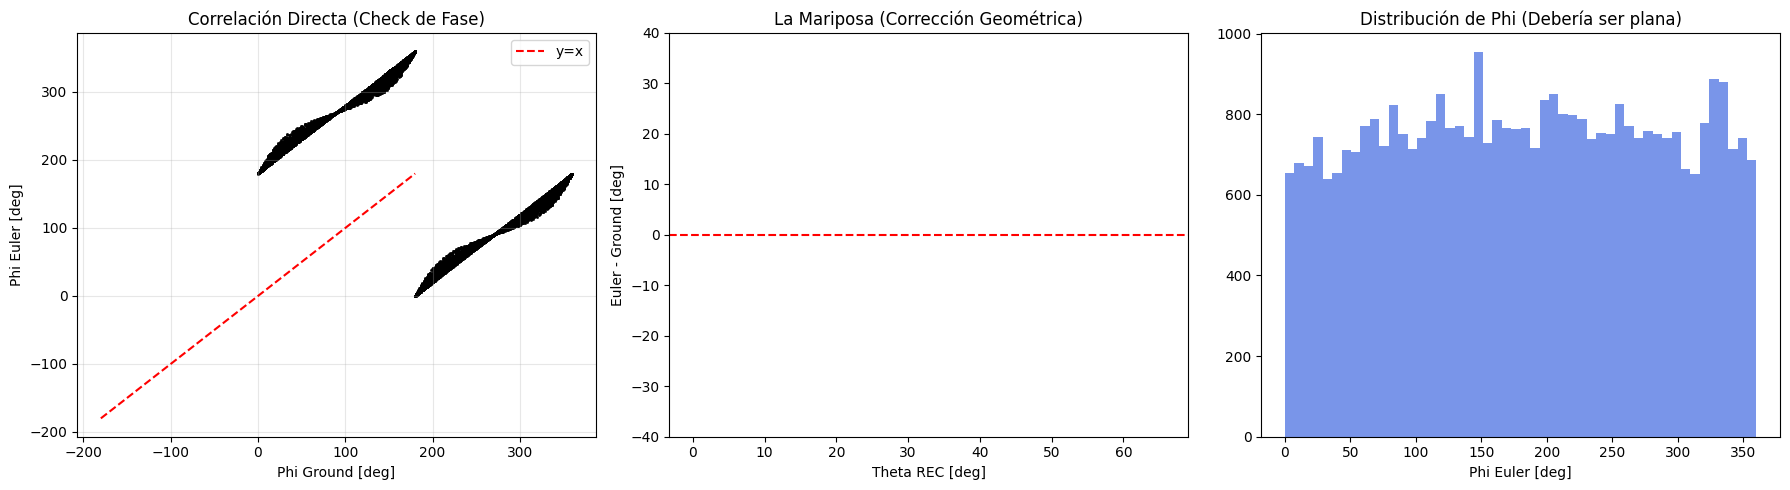


--- Muestra de Datos (Primeras 5 filas) ---
    theta_REC  phi_plane_euler  phi_plane_ground
36  44.551923         5.079287          2.062854
37  44.551923         5.079287          2.062854
38  44.551923         5.079287          2.062854
39  44.551923         1.366520          4.430155
40  44.551923         1.366520          4.430155

Diferencia promedio: -2.179314281809285


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --- 1. CONFIGURACIÓN ---
# Reemplaza con la ruta a TUS parquets procesados con la v12
carpeta_parquets = "/home/lsilva/Github/ADST_Alexey_module_v8/parquet_qgs_helio_17/" 

# --- 2. CARGA DE DATOS ---
files = sorted(glob.glob(os.path.join(carpeta_parquets, "*.parquet")))
if not files:
    raise FileNotFoundError("No encontré parquets en esa ruta.")

# Cargamos solo el primero para testear rápido
df = pd.read_parquet(files[0])
print(f"Archivo cargado: {os.path.basename(files[0])}")

# Filtramos Infill (usando tu lógica nueva de counterId)
df_infill = df[df['counterId'] >= 100000].copy()
print(f"Eventos Infill detectados: {len(df_infill)}")

if len(df_infill) == 0:
    print("⚠️ ALERTA: No hay Infill. Revisa si el pipeline guardó los IDs > 100k.")
else:
    # --- 3. FUNCIONES AUXILIARES ---
    def safe_check_units(series, name):
        """Chequea si son grados o radianes"""
        max_val = series.abs().max()
        print(f"Variable '{name}': Max={max_val:.2f} -> ", end="")
        if max_val > 7.0:
            print("Parecen GRADOS")
            return series
        else:
            print("Parecen RADIANES (Convirtiendo...)")
            return np.rad2deg(series)

    def ang_diff(a, b):
        """Diferencia angular segura (-180 a 180)"""
        return (a - b + 180) % 360 - 180

    # --- 4. NORMALIZACIÓN ---
    print("\n--- Chequeo de Unidades ---")
    theta = df_infill['theta_REC'] # Asumimos grados
    phi_euler  = safe_check_units(df_infill['phi_plane_euler'], 'Euler')
    phi_ground = safe_check_units(df_infill['phi_plane_ground'], 'Ground')
    
    # --- 5. VISUALIZACIÓN DIAGNÓSTICA ---
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # A) Scatter directo 1 a 1 (¿Están correlacionados?)
    # Si todo está bien, deberían formar una línea diagonal perfecta
    axs[0].scatter(phi_ground, phi_euler, s=1, alpha=0.5, c='k')
    axs[0].plot([-180, 180], [-180, 180], 'r--', label='y=x')
    axs[0].set_xlabel("Phi Ground [deg]")
    axs[0].set_ylabel("Phi Euler [deg]")
    axs[0].set_title("Correlación Directa (Check de Fase)")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # B) La Mariposa (Euler - Ground)
    # Aquí es donde veremos si el cálculo geométrico tiene sentido
    diff = ang_diff(phi_euler, phi_ground)
    axs[1].scatter(theta, diff, s=1, alpha=0.5, c=df_infill['r_core'], cmap='viridis')
    axs[1].axhline(0, color='r', linestyle='--')
    axs[1].set_xlabel("Theta REC [deg]")
    axs[1].set_ylabel("Euler - Ground [deg]")
    axs[1].set_title("La Mariposa (Corrección Geométrica)")
    axs[1].set_ylim(-40, 40) # Zoom en la zona de interés
    
    # C) Histograma de Phi Euler
    # Debe ser plano (uniforme) si la lluvia cae de cualquier lado
    axs[2].hist(phi_euler, bins=50, color='royalblue', alpha=0.7)
    axs[2].set_xlabel("Phi Euler [deg]")
    axs[2].set_title("Distribución de Phi (Debería ser plana)")

    plt.tight_layout()
    plt.show()

    # --- 6. IMPRESIÓN DE DATOS CRUDOS ---
    print("\n--- Muestra de Datos (Primeras 5 filas) ---")
    cols = ['theta_REC', 'phi_plane_euler', 'phi_plane_ground']
    print(df_infill[cols].head(5))
    print("\nDiferencia promedio:", diff.mean())

/tmp/ipykernel_2836499/3082695483.py:74: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lsilva/Github/Tesis-de-Licenciatura---ITeDA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


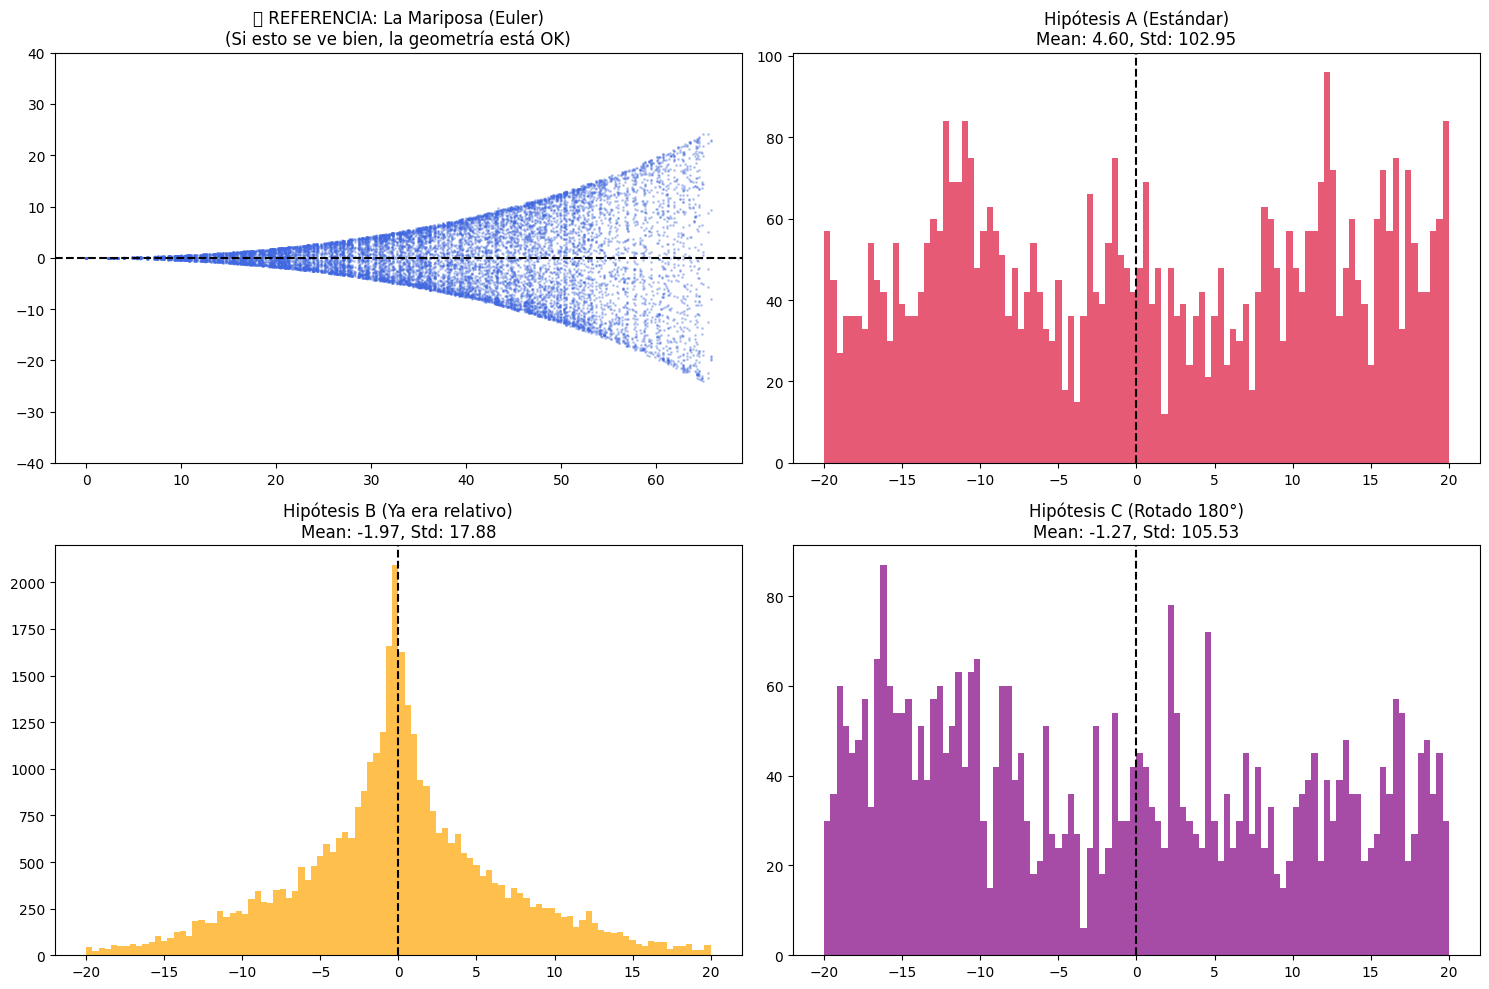

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --- CONFIGURACIÓN ---
carpeta_parquets = "/home/lsilva/Github/ADST_Alexey_module_v8/parquet_qgs_helio_17/" 
files = sorted(glob.glob(os.path.join(carpeta_parquets, "*.parquet")))
df = pd.read_parquet(files[0])

# Filtro Infill Robusto
df_infill = df[
    (df['sdId'] > 2000) & 
    ((df['sdId'] < 90000) | (df['sdId'] >= 100000))
].copy()

if len(df_infill) > 0:
    # --- 1. PREPARACIÓN DE DATOS ---
    # Convertimos todo a GRADOS primero
    def to_deg(s): return np.rad2deg(s) if s.abs().max() < 7.0 else s
    def ang_diff(a, b): return (a - b + 180) % 360 - 180

    theta = df_infill['theta_REC']
    phi_ground_rel = to_deg(df_infill['phi_plane_ground']) # Ya es (Ground - Shower)
    phi_sp_raw = to_deg(df_infill['phi_plane_sp']) # Esto es lo que el pipeline calculó
    phi_euler_aligned = (to_deg(df_infill['phi_plane_euler']) + 180) % 360 # Mariposa arreglada
    
    # RECUPERAMOS EL SP ORIGINAL (CRUDO) DEL ARCHIVO
    # El pipeline hizo: phi_sp_raw = val_sp - rec_phi
    # Entonces: val_sp = phi_sp_raw + rec_phi
    rec_phi = to_deg(df_infill['phi_REC'])
    val_sp_original = (phi_sp_raw + rec_phi) % 360

    # --- 2. TRES HIPÓTESIS PARA RECUPERAR LA CAMPANA ---
    
    # Hipótesis A: El dato es Absoluto (Lo que asume tu código actual)
    # Diff = (SP_Abs - Shower) - (Ground_Abs - Shower)
    diff_A = ang_diff(val_sp_original - rec_phi, phi_ground_rel)

    # Hipótesis B: El dato ya es Relativo (Quizás cambió en QGS)
    # Diff = SP_Rel - (Ground_Abs - Shower)
    diff_B = ang_diff(val_sp_original, phi_ground_rel)
    
    # Hipótesis C: Está rotado 180 grados (Fase invertida)
    # Diff = (SP_Abs - Shower + 180) - Ground_Rel
    diff_C = ang_diff(val_sp_original - rec_phi + 180, phi_ground_rel)

    # --- 3. PLOTEO DIAGNÓSTICO ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. LA MARIPOSA (Ya sabemos que anda, la ponemos de referencia)
    diff_euler = ang_diff(phi_euler_aligned, phi_ground_rel)
    axs[0,0].scatter(theta, diff_euler, s=1, alpha=0.1, c='royalblue')
    axs[0,0].set_title("✅ REFERENCIA: La Mariposa (Euler)\n(Si esto se ve bien, la geometría está OK)")
    axs[0,0].set_ylim(-40, 40)
    axs[0,0].axhline(0, c='k', ls='--')

    # 2. HIPÓTESIS A (Tu código actual)
    axs[0,1].hist(diff_A, bins=100, range=(-20, 20), color='crimson', alpha=0.7)
    axs[0,1].set_title(f"Hipótesis A (Estándar)\nMean: {diff_A.mean():.2f}, Std: {diff_A.std():.2f}")
    axs[0,1].axvline(0, c='k', ls='--')

    # 3. HIPÓTESIS B (Sin restar Shower)
    axs[1,0].hist(diff_B, bins=100, range=(-20, 20), color='orange', alpha=0.7)
    axs[1,0].set_title(f"Hipótesis B (Ya era relativo)\nMean: {diff_B.mean():.2f}, Std: {diff_B.std():.2f}")
    axs[1,0].axvline(0, c='k', ls='--')

    # 4. HIPÓTESIS C (Rotado 180)
    axs[1,1].hist(diff_C, bins=100, range=(-20, 20), color='purple', alpha=0.7)
    axs[1,1].set_title(f"Hipótesis C (Rotado 180°)\nMean: {diff_C.mean():.2f}, Std: {diff_C.std():.2f}")
    axs[1,1].axvline(0, c='k', ls='--')

    plt.tight_layout()
    plt.show()

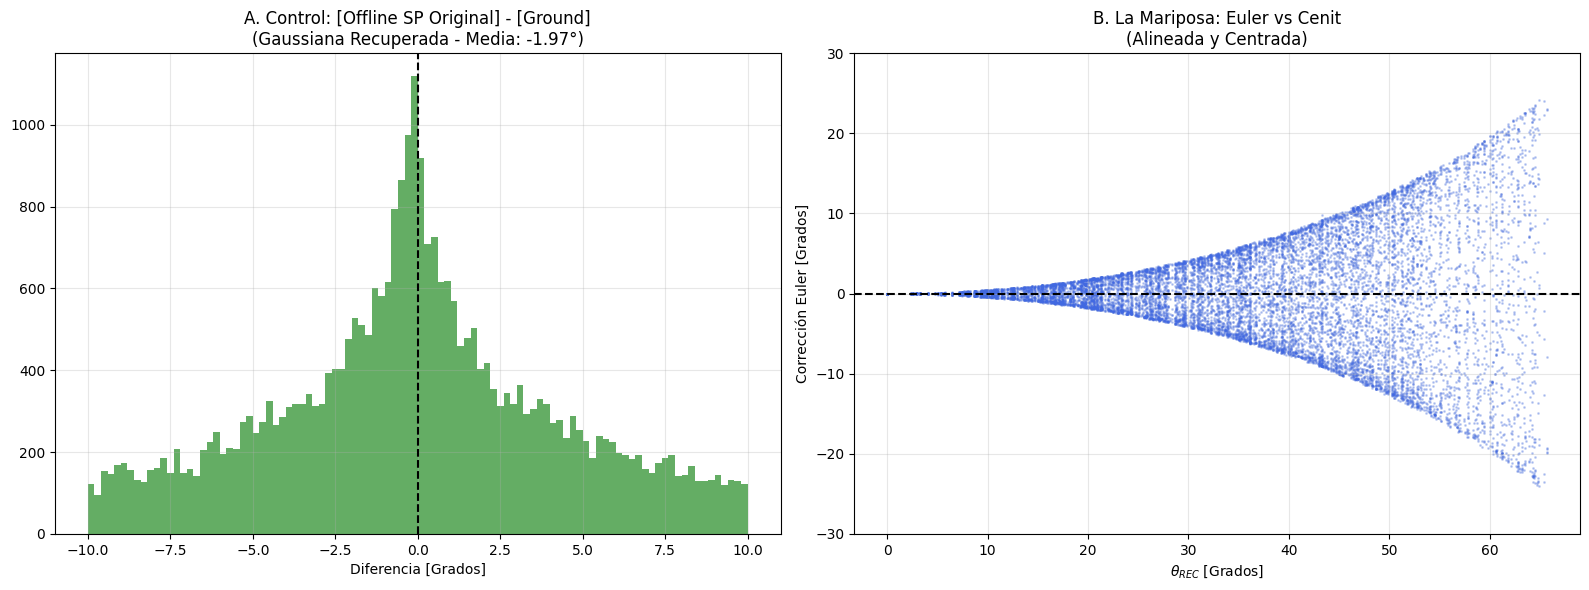

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --- 1. CONFIGURACIÓN ---
carpeta_parquets = "/home/lsilva/Github/ADST_Alexey_module_v8/parquet_qgs_helio_17/" 
files = sorted(glob.glob(os.path.join(carpeta_parquets, "*.parquet")))
df = pd.read_parquet(files[0])

# Filtro Infill Robusto
df_infill = df[
    (df['sdId'] > 2000) & 
    ((df['sdId'] < 90000) | (df['sdId'] >= 100000))
].copy()

if len(df_infill) > 0:
    # --- 2. FUNCIONES Y NORMALIZACIÓN ---
    def ensure_degrees(series):
        if series.abs().max() < 7.0: return np.rad2deg(series)
        return series

    def ang_diff_deg(a, b):
        return (a - b + 180) % 360 - 180

    # Variables básicas
    theta = df_infill['theta_REC']
    phi_ground = ensure_degrees(df_infill['phi_plane_ground'])
    phi_rec = ensure_degrees(df_infill['phi_REC']) # Ángulo de la lluvia
    
    # --- 3. CORRECCIONES "EN CALIENTE" ---
    
    # A. CORRECCIÓN MARIPOSA (EULER)
    # Euler necesita una rotación de 180° para alinearse con la definición de Ground
    phi_euler_raw = ensure_degrees(df_infill['phi_plane_euler'])
    phi_euler_fixed = (phi_euler_raw + 180) % 360
    
    # B. CORRECCIÓN CAMPANA (SP) - ¡LA SOLUCIÓN A TU PROBLEMA!
    # El pipeline restó phi_rec erróneamente. Se lo sumamos para recuperar el valor original.
    phi_sp_from_pipeline = ensure_degrees(df_infill['phi_plane_sp'])
    phi_sp_fixed = (phi_sp_from_pipeline + phi_rec) % 360

    # --- 4. CÁLCULO DE DIFERENCIAS FINALES ---
    diff_mariposa = ang_diff_deg(phi_euler_fixed, phi_ground)
    diff_campana = ang_diff_deg(phi_sp_fixed, phi_ground)

    # --- 5. PLOTEO ---
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: La Campana (Validación SP)
    axs[0].hist(diff_campana, bins=100, range=(-10, 10), color='forestgreen', alpha=0.7)
    axs[0].set_title(f"A. Control: [Offline SP Original] - [Ground]\n(Gaussiana Recuperada - Media: {diff_campana.mean():.2f}°)")
    axs[0].set_xlabel("Diferencia [Grados]")
    axs[0].axvline(0, color='k', linestyle='--')
    axs[0].grid(True, alpha=0.3)

    # Plot 2: La Mariposa (Validación Euler)
    axs[1].scatter(theta, diff_mariposa, s=1, alpha=0.1, c='royalblue')
    axs[1].set_title("B. La Mariposa: Euler vs Cenit\n(Alineada y Centrada)")
    axs[1].set_xlabel(r"$\theta_{REC}$ [Grados]")
    axs[1].set_ylabel("Corrección Euler [Grados]")
    axs[1].set_ylim(-30, 30)
    axs[1].axhline(0, color='k', linestyle='--')
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
else:
    print("No se encontraron datos.")